In [29]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from Bio import SeqIO



pep_hits_long = pd.read_csv('long_non_neut_samples_092326.csv')

In [30]:
lassa = pep_hits_long[pep_hits_long['species'] == 'Mammarenavirus lassaense'].copy()

## importing the reference sequences fetched from UniProt (UP000002473_11622.fasta)

In [31]:
records = list(SeqIO.parse('UP000002473_11622_LASV_Josiah_reference.fasta', 'fasta'))

for r in records:
    print(r.id, len(r.seq))

sp|O09705|L_LASSJ 2218
sp|O73557|Z_LASSJ 99
sp|P08669|GLYC_LASSJ 491
sp|P13699|NCAP_LASSJ 569


In [32]:
reference_by_protein = {
    "polymerase": str(next(r.seq for r in records if "O09705" in r.id)),
    "glycoprotein": str(next(r.seq for r in records if "P08669" in r.id)),
    "nucleoprotein": str(next(r.seq for r in records if "P13699" in r.id)),
    "z protein": str(next(r.seq for r in records if "O73557" in r.id)),
}

In [33]:
print(lassa['category'].value_counts())
print(lassa['sequence'].nunique())
print(lassa['protein_std'].unique())

category
Household contact    41538
Lassa survivor        7224
Name: count, dtype: int64
258
['nucleoprotein' 'polymerase' 'glycoprotein' 'z protein']


## import PairwiseAligner and use BLOSUM62 matrix for local protein alignment

In [34]:
from Bio.Align import PairwiseAligner
from Bio.Align import substitution_matrices

aligner = PairwiseAligner()
aligner.mode = 'local' #want the peptide to find its best location within the reference

aligner.substitution_matrix = substitution_matrices.load("BLOSUM62")
aligner.open_gap_score = -10
aligner.extend_gap_score = -0.5

## first nucleoprotein

In [35]:
ref = reference_by_protein['nucleoprotein']

np = lassa[lassa['protein_std'].eq("nucleoprotein")].copy()

unique_np_peptides = np['sequence'].drop_duplicates()

In [36]:
ref

'MSASKEIKSFLWTQSLRRELSGYCSNIKLQVVKDAQALLHGLDFSEVSNVQRLMRKERRDDNDLKRLRDLNQAVNNLVELKSTQQKSILRVGTLTSDDLLILAADLEKLKSKVIRTERPLSAGVYMGNLSSQQLDQRRALLNMIGMSGGNQGARAGRDGVVRVWDVKNAELLNNQFGTMPSLTLACLTKQGQVDLNDAVQALTDLGLIYTAKYPNTSDLDRLTQSHPILNMIDTKKSSLNISGYNFSLGAAVKAGACMLDGGNMLETIKVSPQTMDGILKSILKVKKALGMFISDTPGERNPYENILYKICLSGDGWPYIASRTSITGRAWENTVVDLESDGKPQKADSNNSSKSLQSAGFTAGLTYSQLMTLKDAMLQLDPNAKTWMDIEGRPEDPVEIALYQPSSGCYIHFFREPTDLKQFKQDAKYSHGIDVTDLFATQPGLTSAVIDALPRNMVITCQGSDDIRKLLESQGRKDIKLIDIALSKTDSRKYENAVWDQYKDLCHMHTGVVVEKKKRGGKEEITPHCALMDCIMFDAAVSGGLNTSVLRAVLPRDMVFRTSTPRVVL'

## define mapping function

In [37]:
def map_peptide_to_reference(peptide, reference, aligner):
    """
    goal: map a peptide onto a reference protein. 

    output: returns a dictionary containing
    - alignment score
    - reference start/end (1-based)
    - reference positions covered by aligned peptide residues
    """

    #if no exact substring match, use local alignment
    alignment = aligner.align(reference, peptide)[0] #[0] to extract the first and best-scoring Alignment object from the results

    #aligner.align[0].aligned returns the start and end coordinates of the aligned segments for the target and query sequences
    ref_blocks, peptide_blocks = alignment.aligned

    ref_positions = []

    for (ref_start, ref_end), (pep_start, pep_end) in zip(ref_blocks, peptide_blocks):
        
        for i in range(ref_end - ref_start):
            ref_positions.append(ref_start + i + 1) #1-based

    #overall peptide coordinates
    pep_start = peptide_blocks[0][0] + 1
    pep_end = peptide_blocks[-1][1] #take the last block,so -1, in case there are more than one aligned blocks. and [1] for the end

    #total number of peptide residues included in the aligned blocks
    aligned_length = sum(end - start for start, end in peptide_blocks)

    #total number 

    return{
        'score': alignment.score, 
        'ref_start': ref_positions[0],
        'ref_end': ref_positions[-1],
        'ref_positions': ref_positions, 
        'pep_start' : pep_start, 
        'pep_end': pep_end,
        'aligned_length': aligned_length
    }


In [38]:
mapping = []

for peptide in unique_np_peptides:
    result = map_peptide_to_reference(peptide, ref, aligner)

    mapping.append({
        'sequence': peptide, 
        'score': result['score'], 
        'ref_start': result['ref_start'], 
        'ref_end': result['ref_end'], 
        'ref_positions': result['ref_positions'], 
        'pep_start': result['pep_start'], 
        'pep_end': result['pep_end'], 
        'aligned_pep_length': result['aligned_length']

    })

np_mapping = pd.DataFrame(mapping)

In [39]:
#check the length of peptide alignment, should be ~46

np_mapping['alignment_length'] = np_mapping['ref_positions'].str.len()

np_mapping['alignment_length'].describe()

count    30.000000
mean     45.900000
std       0.547723
min      43.000000
25%      46.000000
50%      46.000000
75%      46.000000
max      46.000000
Name: alignment_length, dtype: float64

In [40]:
np_mapping.sort_values('aligned_pep_length').head(2)

,sequence,score,ref_start,ref_end,ref_positions,pep_start,pep_end,aligned_pep_length,alignment_length
1,RPGSKESNRSLQTAGFPAGLTYSQLMTLKDSMLQLDPNAKTWMDIE,187.0,349,391,"[349, 350, 351, 352, 353, 354, 355, 356, 357, ...",4,46,43,43
0,TERPLSSGVYMGNLSSQQLDQRRALLNMIGMTGVSGGGKGASNGIV,174.0,116,161,"[116, 117, 118, 119, 120, 121, 122, 123, 124, ...",1,46,46,46


In [41]:
#inspect the shortest mappings: 
np_mapping.sort_values("alignment_length").head(10)

,sequence,score,ref_start,ref_end,ref_positions,pep_start,pep_end,aligned_pep_length,alignment_length
1,RPGSKESNRSLQTAGFPAGLTYSQLMTLKDSMLQLDPNAKTWMDIE,187.0,349,391,"[349, 350, 351, 352, 353, 354, 355, 356, 357, ...",4,46,43,43
0,TERPLSSGVYMGNLSSQQLDQRRALLNMIGMTGVSGGGKGASNGIV,174.0,116,161,"[116, 117, 118, 119, 120, 121, 122, 123, 124, ...",1,46,46,46
2,CSNIKLQVVKDAQALLHGLDFSEVSNIQRLMRKERRDDSDLKRLRD,225.0,24,69,"[24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 3...",1,46,46,46
3,TLNSDDLLTLAADLEKLKSKVVRTERPLSSGVYMGNLSSQQLDQRR,206.0,93,138,"[93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 10...",1,46,46,46
4,TERPLSSGVYMGNLSSQQLDQRRALLNMIGMAGGSQGNQPSRDGVV,198.0,116,161,"[116, 117, 118, 119, 120, 121, 122, 123, 124, ...",1,46,46,46
5,ALLNMIGMAGGSQGNQPSRDGVVRVWDVKNADLLNNQFGTMPSLTL,204.0,139,184,"[139, 140, 141, 142, 143, 144, 145, 146, 147, ...",1,46,46,46
6,KPGNTGSNKSLQSAGFAAGLTYSQLMTLKDSMLQLDPNAKTWIDIE,190.0,346,391,"[346, 347, 348, 349, 350, 351, 352, 353, 354, ...",1,46,46,46
7,TERPLSSGVYMGNLSSQQLDQRRALLNMIGMNGGNQGNQSGRDGVV,211.0,116,161,"[116, 117, 118, 119, 120, 121, 122, 123, 124, ...",1,46,46,46
8,AWENTTVDLESDGKPQKVGTAGSNKSLQSAGFPTGLTYSQLMTLKD,188.0,330,375,"[330, 331, 332, 333, 334, 335, 336, 337, 338, ...",1,46,46,46
9,QFKQDAKYSHGIDVADLFPAQPGLTSAVIEALPRNMVLTCQGSDDI,217.0,422,467,"[422, 423, 424, 425, 426, 427, 428, 429, 430, ...",1,46,46,46


## merging the mapping back to the individual-level dataframe


In [42]:
np = np.merge(np_mapping, on='sequence', how='left')

In [43]:
np.shape

(5670, 26)

## .explode() turns one peptide/individual row to one row per amino-acid position covered by that peptide

In [44]:
np_residues = np.explode('ref_positions').rename(columns={'ref_positions': 'position'})

## keep only reactive peptides

In [45]:
reactive_residues = np_residues[np_residues['reactive']].copy()

## now we have the people and amino acid positions at which they have nucleoprotein antibody reactivity. But we need to remove contributions to the same amino-acid position. each individual can contribute at most one to a given amino acid position. 

In [46]:
reactive_residues = reactive_residues[['individual', 'cohort', 'category', 'position']].drop_duplicates()

In [47]:
reactive_residues['individual'].unique() #no US healthies, as expected

array(['C-130-2_3_C3', 'C-135-2_1_D2', 'C-140-1_1_A7', 'C-183-1_1_F4',
       'C-434-3_5_E2', 'C-438-1_3_A4', 'C-441-3_2_G4', 'C-444-2_2_E4',
       'C-483-1_1_D9', 'C-485-3_2_H3', 'C-499-3_1_B2', 'C-505-2_4_C2',
       'S-502_SA4_I1', 'C-109-1_5_B3', 'C-137-3_2_A9', 'C-139-2_6_D5',
       'C-145-2_2_A6', 'C-148-3_1_G3', 'C-178-1_1_E1', 'C-448-1_1_I4',
       'C-462-2_2_D4', 'C-465-3_5_G8', 'C-467-2_7_H4', 'C-506-2_4_C6',
       'S-462_SA2_I3', 'S-469_SA2_I8', 'S-498_SA1_H6', 'C-124-3_3_C2',
       'C-125-3_3_E5', 'C-126-1_1_E7', 'C-128-1_2_F9', 'C-135-3_1_C9',
       'C-136-1_1_H4', 'C-448-2_1_F8', 'C-465-1_5_H4', 'C-472-2_2_G1',
       'C-486-3_1_C7', 'C-498-2_1_A6', 'S-485_SA2_E1', 'S-507_SA3_D3',
       'C-112-2_2_A4', 'C-113-1_1_D4', 'C-115-1_1_I8', 'C-116-2_2_I1',
       'C-116-3_2_I2', 'C-134-3_3_B1', 'C-135-1_1_A1', 'C-143-2_2_A2',
       'C-146-1_1_H9', 'C-146-2_1_F7', 'C-147-1_3_C6', 'C-150-1_1_H2',
       'C-181-1_1_F3', 'C-184-1_2_G6', 'C-439-1_1_I5', 'C-440-2_2_D3',
      

## calculate number of individuals in each category

In [48]:
group_sizes = (
    np[['individual', 'cohort', 'category']].drop_duplicates().groupby(['cohort', 'category']).size().rename('n_individuals').reset_index()
)

group_sizes

,cohort,category,n_individuals
0,SL,Household contact,161
1,SL,Lassa survivor,28


## now count reactive individuals at each position

In [49]:
position_counts = (
    reactive_residues.groupby(['cohort', 'category', 'position'])['individual'] #reactive residues only include SL individuals
    .nunique()
    .rename('n_seroreactive')
    .reset_index()
)

position_counts.head(2)

,cohort,category,position,n_seroreactive
0,SL,Household contact,24,30
1,SL,Household contact,25,30


In [50]:
position_summary = position_counts.merge(group_sizes, on=['cohort', 'category'], how='left')

position_summary.head(2)

,cohort,category,position,n_seroreactive,n_individuals
0,SL,Household contact,24,30,161
1,SL,Household contact,25,30,161


In [51]:
position_summary['pct_seroreactive'] = (
    position_summary['n_seroreactive'] / position_summary['n_individuals'] * 100
)

In [52]:
position_summary.head(3)

,cohort,category,position,n_seroreactive,n_individuals,pct_seroreactive
0,SL,Household contact,24,30,161,18.63354
1,SL,Household contact,25,30,161,18.63354
2,SL,Household contact,26,30,161,18.63354


## add positions with zero seroreactivity 

In [53]:
all_positions = pd.DataFrame({'position': range(1, len(ref) + 1)}) #initiate a dataframe with one column

groups = np[['cohort', 'category']].drop_duplicates()

complete_grid = groups.merge(all_positions, how='cross')

complete_grid.head(2)

,cohort,category,position
0,SL,Household contact,1
1,SL,Household contact,2


In [54]:
position_summary = complete_grid.merge(
    position_summary,
    on=["cohort", "category", "position"],
    how="left"
)

position_summary["n_seroreactive"] = (
    position_summary["n_seroreactive"]
    .fillna(0)
)

position_summary = position_summary.drop(columns='n_individuals').merge(group_sizes, on=['cohort', 'category'], how='left')

position_summary['pct_seroreactive'] = 100 * position_summary['n_seroreactive'] / position_summary['n_individuals']

In [55]:
position_summary

,cohort,category,position,n_seroreactive,pct_seroreactive,n_individuals
0,SL,Household contact,1,0.0,0.0,161
1,SL,Household contact,2,0.0,0.0,161
2,SL,Household contact,3,0.0,0.0,161
3,SL,Household contact,4,0.0,0.0,161
4,SL,Household contact,5,0.0,0.0,161
...,...,...,...,...,...,...
1133,SL,Lassa survivor,565,0.0,0.0,28
1134,SL,Lassa survivor,566,0.0,0.0,28
1135,SL,Lassa survivor,567,0.0,0.0,28
1136,SL,Lassa survivor,568,0.0,0.0,28


## Now going to plot the % of cohort/ category reactive to the amino acid positions of the nucleoprotein

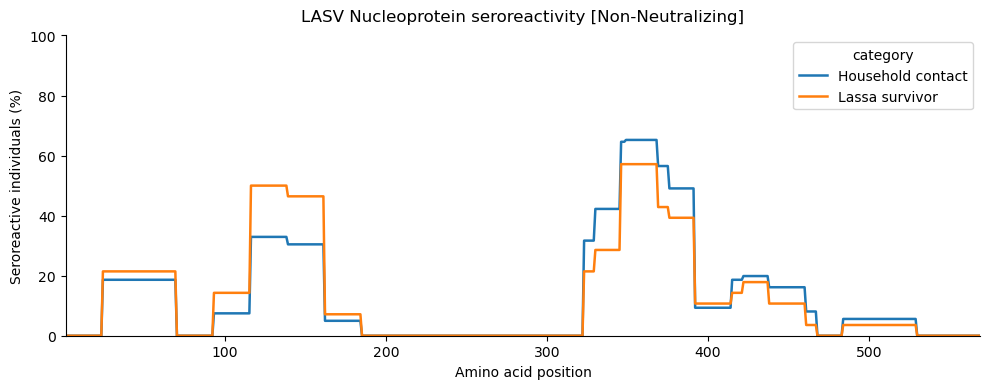

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(10, 4))

sns.lineplot(
    data= position_summary, 
    x='position', 
    y='pct_seroreactive', 
    hue='category', 
    linewidth=1.8, 
    ax=ax
)

ax.set_xlabel('Amino acid position')
ax.set_ylabel('Seroreactive individuals (%)')
ax.set_xlim(1, len(ref)) #minimum and maximum position
ax.set_ylim(0,  100)

ax.spines['top'].set_visible(False)
ax.spines["right"].set_visible(False)

plt.title('LASV Nucleoprotein seroreactivity [Non-Neutralizing]', y=1.02)
plt.tight_layout()
plt.rcParams['svg.fonttype'] = 'none'
plt.savefig('nucleoprotein_reactivity_non_neut.svg', format='svg')
plt.show()